# Notebook 04 — Composite Drought Index (CDI) and Validation

This notebook combines the three drought indices (VCI, TCI, SPI) into a unified Composite Drought Index and validates model robustness.

| Step | Description |
|------|-------------|
| Normalization | Transform SPI to 0–100 scale to match VCI/TCI |
| CDI Computation | Weighted average of all three indices |
| Sensitivity Analysis | Compare equal vs. VCI-weighted schemes |
| Categorization | Classify drought severity levels |
| Export| Save processed datasets for dashboard and analysis |

Key finding: High correlation (r = 0.98) between weighting schemes confirms model robustness.

Outputs: 

`afg_drought_indicators_2000_2025.csv` 

`afg_district_drought_summary.csv`

In [14]:
# Imports and project paths
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT / "data" / "interim"
output_dir = PROJECT_ROOT / "data" / "processed"

In [15]:
# Load the indicators dataset (saved from Notebook 03)
# This dataset contains VCI, TCI, and SPI-3 computed for all 399 districts from 2000-2025.
df = pd.read_csv(data_dir / "afg_indicators_2000_2025.csv")
df["date"] = pd.to_datetime(df["date"])


print(f"\nDataset shape: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())


Dataset shape: (122493, 35)

Columns available:
['date', 'ADM2_CODE', 'ADM2_NAME', 'ADM1_NAME', 'NDVI', 'LST', 'RAIN', 'year', 'month', 'NDVI_filled', 'LST_filled', 'NDVI_was_filled', 'LST_was_filled', 'NDVI_p05', 'NDVI_p95', 'NDVI_baseline_count', 'NDVI_baseline_mean', 'VCI', 'VCI_clipped', 'VCI_out_of_range', 'LST_p05', 'LST_p95', 'LST_baseline_count', 'LST_baseline_mean', 'TCI', 'TCI_clipped', 'TCI_out_of_range', 'RAIN_3m', 'gamma_shape', 'gamma_scale', 'zero_prob', 'gamma_fit_success', 'SPI', 'SPI_gamma_fit_failed', 'any_quality_flag']


---
## Normalize SPI to 0–100 Scale

SPI follows a standard normal distribution (mean=0, std=1, range ≈ -3 to +3). To combine with VCI and TCI, we transform to a 0–100 scale:

$$\text{SPI}_{\text{norm}} = 50 + \text{SPI} \times 16.67$$

| SPI | SPI_norm | Interpretation |
|-----|----------|----------------|
| -3 | 0 | Extreme drought |
| 0 | 50 | Normal conditions |
| +3 | 100 | Extremely wet |

Values beyond ±3 are clipped to maintain the 0–100 range.

In [16]:
# Normalize SPI to 0–100 and clip to 0-100 (values beyond ±3 SPI get clipped)
df["SPI_norm"] = 50 + df["SPI"] * (50 / 3)
df["SPI_norm_clipped"] = df["SPI_norm"].clip(0, 100)

# Summary stats
spi = df["SPI_norm"].dropna()
stats = spi.agg(["count", "mean", "std", "min", "max", "median"])

print("\nSPI_norm distribution:")
for k in ["count", "mean", "std", "min", "max", "median"]:
    print(f"  {k.capitalize():<6}: {stats[k]:.2f}")

# Out-of-range counts (pre-clipping)
below_0 = (spi < 0).sum()
above_100 = (spi > 100).sum()
n = len(spi)

print("\nValues outside [0, 100] (before clipping):")
print(f"  Below 0:   {below_0:,} ({below_0/n*100:.2f}%)")
print(f"  Above 100: {above_100:,} ({above_100/n*100:.2f}%)")



SPI_norm distribution:
  Count : 121999.00
  Mean  : 48.38
  Std   : 17.26
  Min   : -56.02
  Max   : 156.02
  Median: 47.74

Values outside [0, 100] (before clipping):
  Below 0:   191 (0.16%)
  Above 100: 116 (0.10%)


## Composite Drought Index (CDI) Computation

Combine VCI, TCI, and SPI into a single index using two weighting schemes:

| Index | VCI | TCI | SPI | Rationale |
|-------|-----|-----|-----|-----------|
| CDI| 0.33 | 0.33 | 0.33 | Equal contribution from vegetation, temperature, and precipitation |
| CDI_alt| 0.50 | 0.30 | 0.20 | Emphasizes vegetation response (often most visible drought signal) |

Handling missing SPI: For ~475 observations (0.44%) where gamma fitting failed (arid regions in September), CDI is computed using VCI and TCI only with proportionally rescaled weights:
- CDI partial: VCI = 0.5, TCI = 0.5
- CDI_alt partial: VCI = 0.625, TCI = 0.375

Interpretation: Higher CDI = healthier/wetter conditions; Lower CDI = drought stress

In [17]:
# Check data availability
has_vci = df["VCI_clipped"].notna()
has_tci = df["TCI_clipped"].notna()
has_spi = df["SPI_norm_clipped"].notna()
has_all_three = has_vci & has_tci & has_spi
has_vci_tci_only = has_vci & has_tci & (~has_spi)

print(f"\nData availability for CDI Computation:")
print(f"  Has all three (VCI, TCI, SPI):   {has_all_three.sum():,} ({has_all_three.sum()/len(df)*100:.2f}%)")
print(f"  Has VCI and TCI only:                {has_vci_tci_only.sum():,} ({has_vci_tci_only.sum()/len(df)*100:.2f}%)")


Data availability for CDI Computation:
  Has all three (VCI, TCI, SPI):   121,999 (99.60%)
  Has VCI and TCI only:                494 (0.40%)


In [18]:
# CDI - Equal Weights (1/3 each)

# Full composite: 1/3 VCI + 1/3 TCI + 1/3 SPI
df.loc[has_all_three, "CDI"] = (
    df.loc[has_all_three, "VCI_clipped"] + 
    df.loc[has_all_three, "TCI_clipped"] + 
    df.loc[has_all_three, "SPI_norm_clipped"]
) / 3

# Partial composite: 1/2 VCI + 1/2 TCI
df.loc[has_vci_tci_only, "CDI"] = (
    df.loc[has_vci_tci_only, "VCI_clipped"] + 
    df.loc[has_vci_tci_only, "TCI_clipped"]
) / 2

# Create partial flag
df["CDI_partial"] = has_vci_tci_only

print(f"Total CDI computed: {df['CDI'].notna().sum():,}")

Total CDI computed: 122,493


In [19]:
# CDI_alt - (0.5/0.3/0.2)
W2_VCI, W2_TCI, W2_SPI = 0.5, 0.3, 0.2

# Full composite: 0.5 VCI + 0.3 TCI + 0.2 SPI
df.loc[has_all_three, "CDI_alt"] = (
    W2_VCI * df.loc[has_all_three, "VCI_clipped"] + 
    W2_TCI * df.loc[has_all_three, "TCI_clipped"] + 
    W2_SPI * df.loc[has_all_three, "SPI_norm_clipped"]
)

# Partial composite: rescales to 0.625 VCI + 0.375 TCI
W2_VCI_partial = W2_VCI / (W2_VCI + W2_TCI)
W2_TCI_partial = W2_TCI / (W2_VCI + W2_TCI)

df.loc[has_vci_tci_only, "CDI_alt"] = (
    W2_VCI_partial * df.loc[has_vci_tci_only, "VCI_clipped"] + 
    W2_TCI_partial * df.loc[has_vci_tci_only, "TCI_clipped"]
)

print(f"Total CDI_alt computed: {df['CDI_alt'].notna().sum():,}")

Total CDI_alt computed: 122,493


In [20]:
# CDI Sanity Checks

# CDI range check
cols = ["CDI", "CDI_alt"]

print("\nCDI Range Check:")

in_range = ((df[cols] >= 0) & (df[cols] <= 100)).sum()
n_total = df[cols].notna().sum()

for c in cols:
    print(f"\n  {c}:")
    print(f"    Observations within range [0, 100]:")
    print(f"    {in_range[c]:,} ({in_range[c] / n_total[c] * 100:.1f}%)")

# CDI distribution statistics
print("\n\nDistribution:\n")

stats = df[cols].describe().loc[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

print(stats.round(2))


CDI Range Check:

  CDI:
    Observations within range [0, 100]:
    122,493 (100.0%)

  CDI_alt:
    Observations within range [0, 100]:
    122,493 (100.0%)


Distribution:

             CDI    CDI_alt
count  122493.00  122493.00
mean       49.63      49.90
std        20.16      22.40
min         0.00       0.00
25%        34.92      33.46
50%        49.72      49.80
75%        64.38      66.65
max       100.00     100.00


## Weight Sensitivity Analysis

Assess model robustness by comparing the two weighting schemes. A high correlation indicates the composite index is stable regardless of weight choice.

Results:
- Pearson correlation: r = 0.98 (excellent agreement)
- <7.5% of observations differ by more than 10 points

Note on scatter plot "wings": The diagonal spread occurs because VCI has 50% weight in CDI_alt vs. 33% in CDI, creating systematic divergence when VCI deviates substantially from TCI and SPI.


Correlation Between CDI's with Different Weights:
   CDI vs CDI_alt: r = 0.9756
  Max difference: 16.67
  95th percentile difference: 9.77


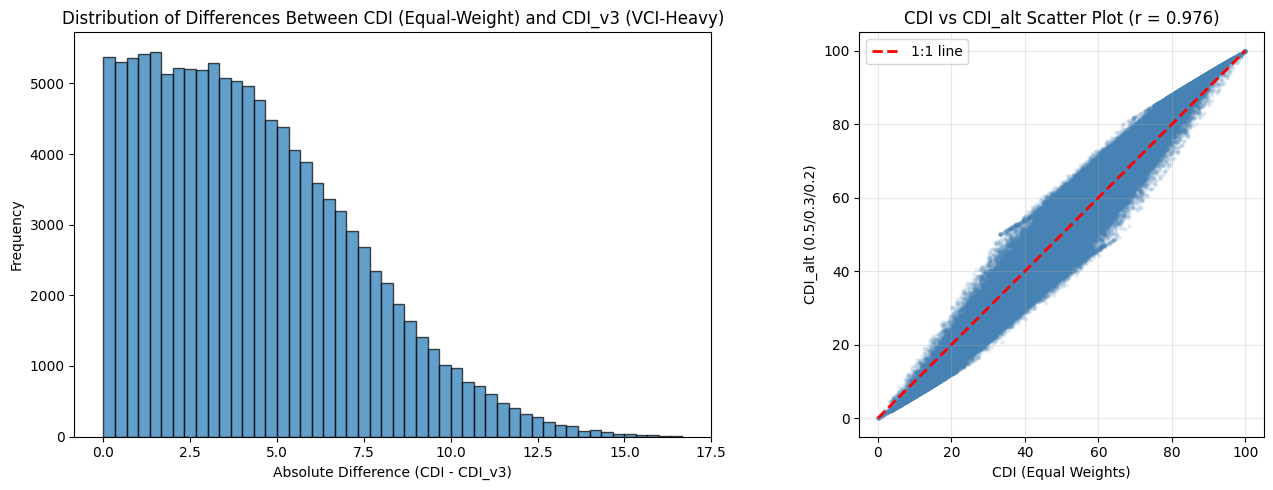

In [21]:
# Correlations between CDI versions
print("\nCorrelation Between CDI's with Different Weights:")

valid_mask = df["CDI"].notna() & df["CDI_alt"].notna()
corr = df.loc[valid_mask, "CDI"].corr(df.loc[valid_mask, "CDI_alt"])
print(f"   CDI vs CDI_alt: r = {corr:.4f}")

# Compare CDI (equal weights) vs CDI_alt (VCI-heavy)
diff = (df.loc[valid_mask, "CDI"] - df.loc[valid_mask, "CDI_alt"]).abs()
print(f"  Max difference: {diff.max():.2f}")
print(f"  95th percentile difference: {diff.quantile(0.95):.2f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram
ax1 = axes[0]
ax1.hist(diff, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Absolute Difference (CDI - CDI_v3)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Differences Between CDI (Equal-Weight) and CDI_v3 (VCI-Heavy)')

# Right: Scatter plot
ax2 = axes[1]
ax2.scatter(df.loc[valid_mask, "CDI"], df.loc[valid_mask, "CDI_alt"], 
            alpha=0.1, s=5, c='steelblue')
ax2.plot([0, 100], [0, 100], 'r--', linewidth=2, label='1:1 line')
ax2.set_xlabel('CDI (Equal Weights)')
ax2.set_ylabel('CDI_alt (0.5/0.3/0.2)')
ax2.set_title(f'CDI vs CDI_alt Scatter Plot (r = {corr:.3f})')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

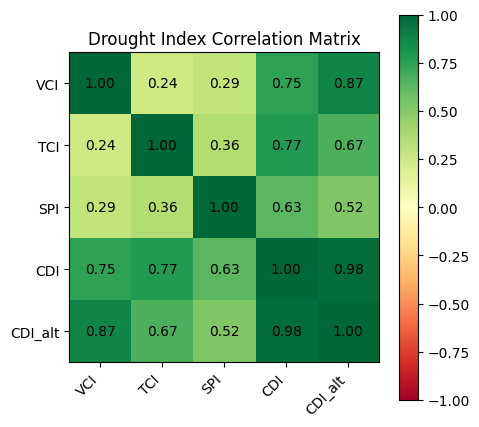

In [22]:
# Correlation Matrix
# Select indices for correlation analysis (rename for visual clarity)
cols = {
    "VCI_clipped": "VCI",
    "TCI_clipped": "TCI",
    "SPI_norm_clipped": "SPI",
    "CDI": "CDI",
    "CDI_alt": "CDI_alt",
}

# Compute correlation matrix
corr = df[list(cols)].rename(columns=cols).corr()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdYlGn")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i, row in enumerate(corr.values):
    for j, val in enumerate(row):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

ax.set_title("Drought Index Correlation Matrix")
plt.show()

## CDI Distribution and Drought Categories

Visualize the CDI distribution and classify observations into drought severity categories:

| CDI Range | Category |
|-----------|----------|
| < 10 | Extreme Drought |
| 10–20 | Severe Drought |
| 20–30 | Moderate Drought |
| 30–40 | Mild Drought |
| 40–50 | Near Normal |
| > 50 | Normal/Wet |

CDI Distribution Analysis


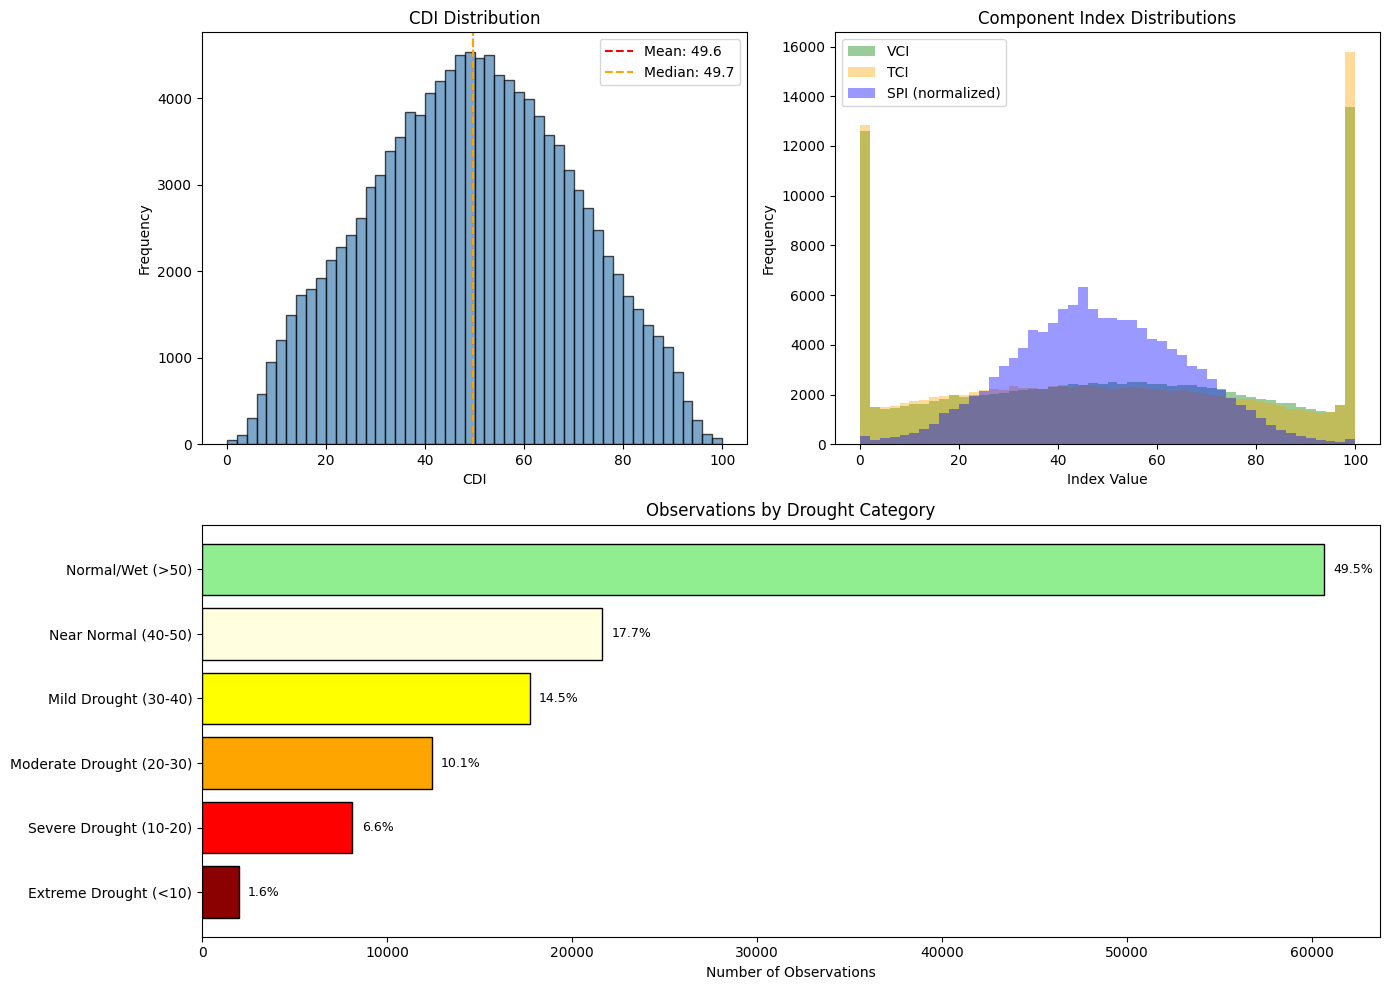

In [23]:
# CDI Distribution Analysis
print("CDI Distribution Analysis")

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# CDI histogram (top left)
ax1 = fig.add_subplot(gs[0, 0])
cdi_valid = df["CDI"].dropna()
ax1.hist(cdi_valid, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=cdi_valid.mean(), color='red', linestyle='--', 
            label=f'Mean: {cdi_valid.mean():.1f}')
ax1.axvline(x=cdi_valid.median(), color='orange', linestyle='--', 
            label=f'Median: {cdi_valid.median():.1f}')
ax1.set_xlabel('CDI')
ax1.set_ylabel('Frequency')
ax1.set_title('CDI Distribution')
ax1.legend()

# Component distributions (top right)
ax2 = fig.add_subplot(gs[0, 1])
for col, color, label in [("VCI_clipped", "green", "VCI"), 
                           ("TCI_clipped", "orange", "TCI"),
                           ("SPI_norm_clipped", "blue", "SPI (normalized)")]:
    vals = df[col].dropna()
    ax2.hist(vals, bins=50, alpha=0.4, label=label, color=color)
ax2.set_xlabel('Index Value')
ax2.set_ylabel('Frequency')
ax2.set_title('Component Index Distributions')
ax2.legend()

# CDI by drought category (bottom, spanning both columns)
ax3 = fig.add_subplot(gs[1, :])

# Define drought categories using fixed thresholds on the 0-100 CDI scale
def categorize_cdi(val):
    if pd.isna(val):
        return "Missing"
    elif val < 10:
        return "Extreme Drought (<10)"
    elif val < 20:
        return "Severe Drought (10-20)"
    elif val < 30:
        return "Moderate Drought (20-30)"
    elif val < 40:
        return "Mild Drought (30-40)"
    elif val < 50:
        return "Near Normal (40-50)"
    else:
        return "Normal/Wet (>50)"

df["drought_category"] = df["CDI"].apply(categorize_cdi)

category_order = ["Extreme Drought (<10)", "Severe Drought (10-20)", "Moderate Drought (20-30)", "Mild Drought (30-40)", "Near Normal (40-50)", "Normal/Wet (>50)"]
category_counts = df["drought_category"].value_counts().reindex(category_order)

colors = ['darkred', 'red', 'orange', 'yellow', 'lightyellow', 'lightgreen']
bars = ax3.barh(category_counts.index, category_counts.values, color=colors, edgecolor='black')
ax3.set_xlabel('Number of Observations')
ax3.set_title('Observations by Drought Category')

# Add percentage labels
total = category_counts.sum()
for bar, count in zip(bars, category_counts.values):
    pct = count / total * 100
    ax3.text(count + 500, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Export Final Datasets

Generate two output files for downstream analysis and the dashboard:

| File | Contents | Rows |
|------|----------|------|
| `afg_drought_indicators_2000_2025.csv` | Full time series with all indices and quality flags | 118,104 |
| `afg_district_drought_summary.csv` | District-level statistics including worst drought dates | 399 |

Date range: March 2000 – December 2025 (first 2 months excluded due to SPI-3 rolling window)

In [24]:
# District-Level Summary Statistics (for dashboard)

grp_cols = ["ADM2_CODE", "ADM2_NAME", "ADM1_NAME"]

# District summary stats
district_summary = (
    df.groupby(grp_cols, as_index=False)
      .agg(
          CDI_mean=("CDI", "mean"),
          CDI_std=("CDI", "std"),
          CDI_min=("CDI", "min"),
          CDI_max=("CDI", "max"),
          CDI_median=("CDI", "median"),
          n_observations=("CDI", "count"),
          n_partial=("CDI_partial", "sum"),
      )
)

# Worst drought date/month per district
worst_idx = df.groupby("ADM2_CODE")["CDI"].idxmin()      
worst_months = (
    df.loc[worst_idx.dropna(), ["ADM2_CODE", "date"]]
      .rename(columns={"date": "worst_drought_date"})
)
district_summary = district_summary.merge(worst_months, on="ADM2_CODE", how="left")
district_summary["worst_drought_month"] = district_summary["worst_drought_date"].dt.strftime("%Y-%m")
district_summary = district_summary.round(2)

print("Summary statistics first 5 rows:\n")
print(district_summary.head(5).to_string(index=False))

Summary statistics first 5 rows:

 ADM2_CODE       ADM2_NAME  ADM1_NAME  CDI_mean  CDI_std  CDI_min  CDI_max  CDI_median  n_observations  n_partial worst_drought_date worst_drought_month
      3448        Eshkmesh Badakhshan     51.87    18.88     8.51    99.88       51.30             307          0         2008-07-01             2008-07
      3452 Koran wa Monjan Badakhshan     51.53    17.56     7.93    92.28       51.73             307          0         2001-04-01             2001-04
      3454  Shahr-e-Buzorg Badakhshan     47.41    21.38     3.07    95.73       46.56             307          0         2008-03-01             2008-03
      3455        Shighnan Badakhshan     50.34    19.41     5.85    95.07       49.32             307          0         2010-12-01             2010-12
      3456          Wakhan Badakhshan     53.69    15.93    11.02    91.68       53.72             307          0         2001-06-01             2001-06


In [25]:
# Data Export - Export final processed dataset with all drought indices and quality flags

# Select columns and create export df
export_cols = [
    "ADM2_CODE", "ADM2_NAME", "ADM1_NAME", "date", "year", "month", # Identifiers
    "VCI", "TCI", "SPI", # Raw indices
    "VCI_clipped", "TCI_clipped", # Clipped indices
    "SPI_norm", "SPI_norm_clipped", # Normalized SPI
    "CDI", "CDI_alt", # Composite indices
    "CDI_partial", # Composite flags
    
    # Quality flags
    "NDVI_was_filled", "LST_was_filled",
    "VCI_out_of_range", "TCI_out_of_range",
    "any_quality_flag"
]
df_export = df[export_cols].copy()
df_export = df_export.sort_values(["ADM2_CODE", "date"]).reset_index(drop=True)

# Export main dataset
main_export_path = output_dir / "afg_drought_indicators_2000_2025.csv"
df_export.to_csv(main_export_path, index=False)
print(f"Final processed dataset exported: Shape {df_export.shape}\n")

# Export district summary
summary_export_path = output_dir / "afg_district_drought_summary.csv"
district_summary.to_csv(summary_export_path, index=False)
print(f"District summary exported: Shape {district_summary.shape}")

Final processed dataset exported: Shape (122493, 21)

District summary exported: Shape (399, 12)
